# Baseline: constant predictor

Establishes the floor that every later model is measured against. A constant predictor ignores the input entirely and always outputs the same number. For MAE the optimal constant is the median of the target; for RMSE it is the mean.

Run this before committing compute to the Stockfish pass. Also computes the total position count so the engine runtime estimate is based on the real ply distribution rather than a guess.

Place in `notebooks/`. Paths are relative to that directory.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "sampled" / "sampled_games_enriched.parquet"
RESULTS_DIR = PROJECT_ROOT / "exploration_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

print(DATA_PATH, DATA_PATH.exists())

/home/mikwal/Desktop/ML/Chess-Project/chess-ml/data/sampled/sampled_games_enriched.parquet True


## Load and inspect

In [2]:
df = pd.read_parquet(DATA_PATH)

print(f"rows: {len(df):,}")
print(f"cols: {df.shape[1]}")
df.dtypes.to_frame("dtype")

rows: 333,478
cols: 18


,dtype
game_id,str
white_elo,int64
black_elo,int64
avg_elo,float64
rating_diff,int64
time_control,str
result,str
termination,str
half_moves,int64
moves_san,str


In [3]:
df.head(5)

,game_id,white_elo,black_elo,avg_elo,rating_diff,time_control,result,termination,half_moves,moves_san,clocks_sec,elo_bin,white,black,utc_date,utc_time,eco,opening
0,LcvjuOZ0,789,810,799.5,-21,600+0,1-0,Normal,39,"e4,g6,d4,d6,Bg5,Nf6,Bc4,Nxe4,f3,Nxg5,Bxf7+,Nxf...","600,600,587,596,576,582,560,567,552,556,546,54...",<800,furburn,nandokellom,2017.04.02,23:53:49,B06,Modern Defense
1,PyAMOZzz,803,781,792.0,22,120+15,1-0,Normal,67,"e4,e5,Qh5,Nf6,Qxf7+,Kxf7,Bc4+,d5,exd5,Bd7,d3,B...","120,120,128,135,130,135,141,134,152,125,165,13...",<800,furburn,lwa5110,2017.04.03,23:48:42,C20,"King's Pawn Game: Wayward Queen Attack, Kiddie..."
2,LHiqlsvH,751,818,784.5,-67,120+15,1/2-1/2,Normal,72,"e4,e5,Nf3,Nc6,Nxe5,Nxe5,f4,Ng6,d3,d6,Be3,Be6,B...","120,120,130,132,140,144,151,145,161,154,173,16...",<800,lwa5110,furburn,2017.04.03,23:58:09,C44,Irish Gambit
3,Jvo0bgaZ,794,804,799.0,-10,600+0,0-1,Normal,54,"e3,Nf6,Nf3,e5,c3,d6,d4,e4,Ng5,g6,Bb5+,Bd7,Bc4,...","600,600,597,598,591,597,574,589,560,582,549,57...",<800,nandokellom,KanchanFromIndia,2017.04.04,11:54:27,A04,Zukertort Opening: Quiet System
4,dyqymIeE,804,795,799.5,9,600+0,0-1,Normal,86,"c4,e5,b3,b5,Ba3,bxc4,Bxf8,Kxf8,Nc3,Nf6,e4,Nc6,...","600,600,594,591,592,584,590,581,585,578,583,56...",<800,angee,Grodey,2017.04.06,16:52:20,A20,English Opening: King's English Variation


## Target construction

Three candidate targets. `elo_mean` is the per-game average and is the one stated as the modelling target. `elo_white` / `elo_black` are kept because splitting the problem into mean-plus-difference was reported to work better than predicting each rating directly.

In [4]:
def find_col(frame, candidates):
    lookup = {c.lower(): c for c in frame.columns}
    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    return None


white_col = find_col(df, ["WhiteElo", "white_elo", "elo_white", "white_rating"])
black_col = find_col(df, ["BlackElo", "black_elo", "elo_black", "black_rating"])

if white_col is None or black_col is None:
    raise KeyError(f"Could not locate rating columns. Available: {list(df.columns)}")

print(f"white: {white_col}   black: {black_col}")

white: white_elo   black: black_elo


In [5]:
targets = pd.DataFrame(
    {
        "elo_white": pd.to_numeric(df[white_col], errors="coerce"),
        "elo_black": pd.to_numeric(df[black_col], errors="coerce"),
    }
)
targets["elo_mean"] = (targets["elo_white"] + targets["elo_black"]) / 2.0
targets["elo_diff"] = targets["elo_white"] - targets["elo_black"]

n_missing = targets.isna().any(axis=1).sum()
print(f"rows with a missing rating: {n_missing:,} ({n_missing / len(targets):.3%})")

targets.describe().T

rows with a missing rating: 0 (0.000%)


,count,mean,std,min,25%,50%,75%,max
elo_white,333478.0,1575.574392,372.666446,751.0,1261.0,1578.0,1883.0,2656.0
elo_black,333478.0,1575.758884,372.551646,760.0,1262.0,1578.0,1883.0,2608.0
elo_mean,333478.0,1575.666638,371.740727,784.5,1263.0,1578.5,1880.5,2632.0
elo_diff,333478.0,-0.184492,50.846299,-100.0,-39.0,0.0,38.0,100.0


## Distribution

The shape of the target determines what a good MAE looks like. A near-uniform target over a wide range produces a much larger baseline MAE than a bell-shaped one over the same range, so this plot is needed to interpret every number below.

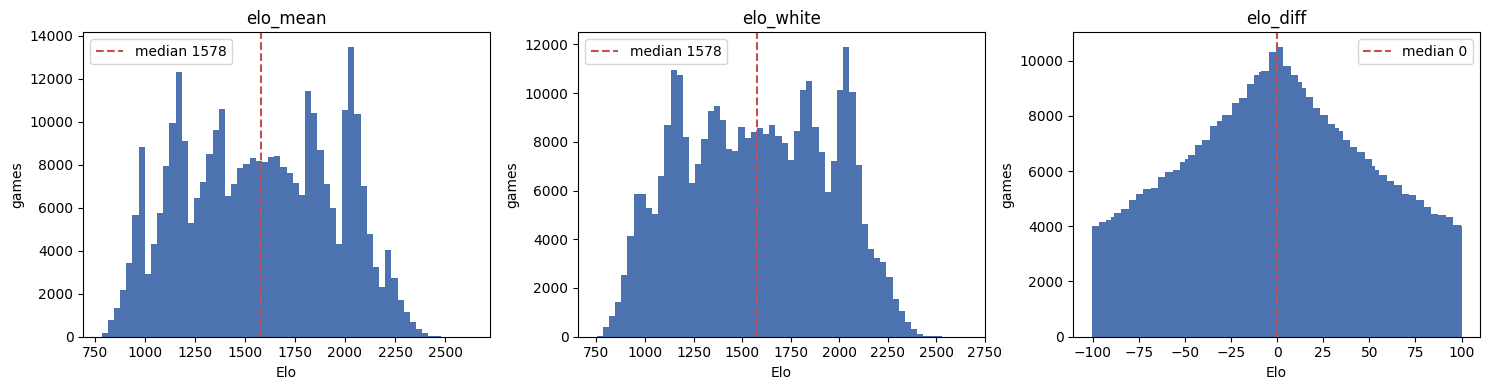

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["elo_mean", "elo_white", "elo_diff"]):
    values = targets[col].dropna()
    if col == "elo_diff":
        edges = np.arange(values.min() - 0.5, values.max() + 1.5, 4)
    else:
        edges = 60
    ax.hist(values, bins=edges, color="#4C72B0", edgecolor="none")
    ax.hist(values, bins=60, color="#4C72B0", edgecolor="none")
    ax.axvline(values.median(), color="#C44E52", linestyle="--", linewidth=1.5, label=f"median {values.median():.0f}")
    ax.set_title(col)
    ax.set_xlabel("Elo")
    ax.set_ylabel("games")
    ax.legend()

fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig_target_distribution.svg")
plt.show()

In [7]:
summary = targets.agg(["count", "mean", "std", "min", "median", "max"]).T
summary["iqr"] = targets.quantile(0.75) - targets.quantile(0.25)
summary

,count,mean,std,min,median,max,iqr
elo_white,333478.0,1575.574392,372.666446,751.0,1578.0,2656.0,622.0
elo_black,333478.0,1575.758884,372.551646,760.0,1578.0,2608.0,621.0
elo_mean,333478.0,1575.666638,371.740727,784.5,1578.5,2632.0,617.5
elo_diff,333478.0,-0.184492,50.846299,-100.0,0.0,100.0,77.0


## Constant predictor

`fit_values` supplies the constant, `eval_values` is where the error is measured. Right now both are the full dataset, which is fine for orientation. After the player-disjoint split exists, call the same function with `fit_values=train`, `eval_values=val` and treat those numbers as the real baseline.

In [8]:
def constant_baseline(fit_values, eval_values):
    fit_values = pd.Series(fit_values).dropna().astype(float)
    eval_values = pd.Series(eval_values).dropna().astype(float)

    median_constant = float(fit_values.median())
    mean_constant = float(fit_values.mean())

    return {
        "n_fit": int(fit_values.size),
        "n_eval": int(eval_values.size),
        "median_constant": median_constant,
        "mean_constant": mean_constant,
        "mae_from_median": float((eval_values - median_constant).abs().mean()),
        "mae_from_mean": float((eval_values - mean_constant).abs().mean()),
        "rmse_from_median": float(np.sqrt(((eval_values - median_constant) ** 2).mean())),
        "rmse_from_mean": float(np.sqrt(((eval_values - mean_constant) ** 2).mean())),
        "std_eval": float(eval_values.std()),
    }


def skill_score(model_error, baseline_error):
    return 1.0 - model_error / baseline_error

In [9]:
baseline_rows = {}
for col in ["elo_mean", "elo_white", "elo_black", "elo_diff"]:
    baseline_rows[col] = constant_baseline(targets[col], targets[col])

baselines = pd.DataFrame(baseline_rows).T
baselines.index.name = "target"
baselines.round(2)

,n_fit,n_eval,median_constant,mean_constant,mae_from_median,mae_from_mean,rmse_from_median,rmse_from_mean,std_eval
target,,,,,,,,,
elo_mean,333478.0,333478.0,1578.5,1575.67,319.53,319.53,371.75,371.74,371.74
elo_white,333478.0,333478.0,1578.0,1575.57,320.05,320.06,372.67,372.67,372.67
elo_black,333478.0,333478.0,1578.0,1575.76,319.95,319.95,372.56,372.55,372.55
elo_diff,333478.0,333478.0,0.0,-0.18,42.19,42.19,50.85,50.85,50.85


In [10]:
primary = baselines.loc["elo_mean"]

print(f"Primary target: elo_mean")
print(f"  constant (median)   : {primary['median_constant']:.0f}")
print(f"  baseline MAE        : {primary['mae_from_median']:.1f}")
print(f"  baseline RMSE       : {primary['rmse_from_mean']:.1f}")
print()
for candidate_mae in [250, 220, 200, 180, 160, 140, 120]:
    print(f"  model at MAE {candidate_mae:>3}  ->  skill score {skill_score(candidate_mae, primary['mae_from_median']):+.3f}")

Primary target: elo_mean
  constant (median)   : 1578
  baseline MAE        : 319.5
  baseline RMSE       : 371.7

  model at MAE 250  ->  skill score +0.218
  model at MAE 220  ->  skill score +0.311
  model at MAE 200  ->  skill score +0.374
  model at MAE 180  ->  skill score +0.437
  model at MAE 160  ->  skill score +0.499
  model at MAE 140  ->  skill score +0.562
  model at MAE 120  ->  skill score +0.624


In [11]:
baselines.round(3).to_csv(RESULTS_DIR / "baseline_constant_predictor.csv")
print(RESULTS_DIR / "baseline_constant_predictor.csv")

/home/mikwal/Desktop/ML/Chess-Project/chess-ml/exploration_results/baseline_constant_predictor.csv


## Second baseline: metadata only

Costs nothing and shows how much of the signal is available without any engine work. Uses only columns already present in the parquet: game length, result, time control, termination. If this already beats the constant predictor by a wide margin, the marginal value of the Stockfish features is smaller than it looks.

In [12]:
ply_col = find_col(df, ["ply_count", "plies", "n_plies", "num_plies", "move_count", "num_moves", "n_moves", "ply"])
moves_col = find_col(df, ["moves", "movetext", "pgn_moves", "uci_moves", "san_moves"])

print(f"ply column   : {ply_col}")
print(f"moves column : {moves_col}")

ply column   : None
moves column : None


In [13]:
if ply_col is not None:
    plies = pd.to_numeric(df[ply_col], errors="coerce")
elif moves_col is not None:
    plies = df[moves_col].astype(str).str.split().str.len()
else:
    plies = None

if plies is not None:
    plies = plies.dropna()
    print(plies.describe().round(1))
else:
    print("No ply or moves column found; skipping.")

No ply or moves column found; skipping.


In [14]:
if plies is not None:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(plies, bins=80, color="#55A868", edgecolor="none")
    ax.axvline(plies.median(), color="#C44E52", linestyle="--", label=f"median {plies.median():.0f}")
    ax.set_xlabel("plies per game")
    ax.set_ylabel("games")
    ax.set_title("Game length")
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "fig_ply_distribution.svg")
    plt.show()

## Position count and engine runtime

Replaces the guessed 80-plies-per-game figure with the measured one. `DEDUP_FACTOR` is the fraction of positions surviving FEN deduplication plus dropping the opening book; 0.70 is a starting assumption to be replaced by a measurement.

`SECONDS_PER_POSITION` must come from a pilot run of a few hundred games at the chosen depth on this machine. The three values below are a plausible range only.

In [15]:
if plies is not None:
    DEDUP_FACTOR = 0.70
    WORKER_COUNTS = [6, 12]
    SECONDS_PER_POSITION = [0.20, 0.35, 0.60]

    raw_positions = int(plies.sum())
    effective_positions = int(raw_positions * DEDUP_FACTOR)

    print(f"raw positions       : {raw_positions:,}")
    print(f"after dedup ({DEDUP_FACTOR:.0%})  : {effective_positions:,}")
    print()

    estimate_rows = []
    for workers in WORKER_COUNTS:
        effective_cores = workers if workers <= 6 else 6 + (workers - 6) * 0.3
        for spp in SECONDS_PER_POSITION:
            hours = effective_positions * spp / effective_cores / 3600
            estimate_rows.append(
                {
                    "workers": workers,
                    "effective_cores": round(effective_cores, 1),
                    "sec_per_position": spp,
                    "hours": round(hours, 1),
                    "days": round(hours / 24, 2),
                }
            )

    estimates = pd.DataFrame(estimate_rows)
    estimates.to_csv(RESULTS_DIR / "engine_runtime_estimate.csv", index=False)
    estimates

## After the split exists

Recompute the baseline with the same function, fitting the constant on train and evaluating on validation. Every model result should be reported next to that number and as a skill score against it.

```python
train = pd.read_parquet(PROJECT_ROOT / "data" / "sampled" / "Splitted" / "train.parquet")
val = pd.read_parquet(PROJECT_ROOT / "data" / "sampled" / "Splitted" / "val.parquet")

train_target = (train[white_col] + train[black_col]) / 2.0
val_target = (val[white_col] + val[black_col]) / 2.0

constant_baseline(train_target, val_target)
```